# 1. THƯ VIỆN VÀ IMPORT

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")
os.makedirs('./images', exist_ok=True)

# Data preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           confusion_matrix, classification_report, roc_auc_score,
                           roc_curve, precision_recall_curve, auc)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Handling imbalanced data
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency

# 2. PROBLEM DEFINITION
- Objective: Classify patients into three categories: ME/CFS, Depression, or Both
- Dataset: Synthetic dataset with clinical features
- Features: Age, gender, sleep quality, brain fog, physical pain, stress, etc.
- Target: Diagnosis (ME/CFS, Depression, Both)
- Challenge: Multi-class classification with potential class imbalance

# 3. DATA COLLECTION

## ME/CFS vs Depression Classification Model Development

Load the dataset

In [134]:
print("\n3. DATA COLLECTION")
print("-" * 50)

try:
    df = pd.read_csv('me_cfs_vs_depression_dataset.csv')
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
except FileNotFoundError:
    print("Error: Dataset file not found!")
    exit(1)



3. DATA COLLECTION
--------------------------------------------------
Dataset loaded successfully!
Shape: (1000, 16)
Columns: ['age', 'gender', 'sleep_quality_index', 'brain_fog_level', 'physical_pain_score', 'stress_level', 'depression_phq9_score', 'fatigue_severity_scale_score', 'pem_duration_hours', 'hours_of_sleep_per_night', 'pem_present', 'work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness', 'diagnosis']


# 4. DATA CLEANING AND PREPROCESSING

## 4.1 Data Information

In [135]:
print("\n4.1 Data Information:")
print(df.info())

print("\n4.2 Basic Statistics:")
print(df.describe())

print("\n4.3 Missing Values Analysis:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
})
print(missing_df[missing_df['Missing_Count'] > 0])



4.1 Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           1000 non-null   int64  
 1   gender                        1000 non-null   object 
 2   sleep_quality_index           953 non-null    float64
 3   brain_fog_level               952 non-null    float64
 4   physical_pain_score           966 non-null    float64
 5   stress_level                  952 non-null    float64
 6   depression_phq9_score         978 non-null    float64
 7   fatigue_severity_scale_score  979 non-null    float64
 8   pem_duration_hours            976 non-null    float64
 9   hours_of_sleep_per_night      979 non-null    float64
 10  pem_present                   1000 non-null   int64  
 11  work_status                   953 non-null    object 
 12  social_activity_level         960 non-nu

## 4.4 Duplicate Values

In [136]:
print(f"\nDuplicate Rows: {df.duplicated().sum()}")



Duplicate Rows: 0


## 4.5 Data Types Analysis

In [137]:
print(df.dtypes)


age                               int64
gender                           object
sleep_quality_index             float64
brain_fog_level                 float64
physical_pain_score             float64
stress_level                    float64
depression_phq9_score           float64
fatigue_severity_scale_score    float64
pem_duration_hours              float64
hours_of_sleep_per_night        float64
pem_present                       int64
work_status                      object
social_activity_level            object
exercise_frequency               object
meditation_or_mindfulness        object
diagnosis                        object
dtype: object


## 4.6 Categorical Variables Analysis

In [138]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical Variables: {list(categorical_cols)}")

for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())



Categorical Variables: ['gender', 'work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness', 'diagnosis']

gender unique values:
gender
Male      524
Female    476
Name: count, dtype: int64

work_status unique values:
work_status
Partially working    335
Working              320
Not working          298
Name: count, dtype: int64

social_activity_level unique values:
social_activity_level
Very low     203
High         200
Low          190
Very high    186
Medium       181
Name: count, dtype: int64

exercise_frequency unique values:
exercise_frequency
Rarely       210
Often        202
Daily        194
Sometimes    184
Never        171
Name: count, dtype: int64

meditation_or_mindfulness unique values:
meditation_or_mindfulness
Yes    505
No     484
Name: count, dtype: int64

diagnosis unique values:
diagnosis
Depression    401
ME/CFS        397
Both          202
Name: count, dtype: int64


## 4.7 Handle Missing Values

Create a copy for preprocessing

In [139]:
df_clean = df.copy()


Strategy 1: For numerical columns, use KNN imputation

In [140]:
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns


Remove target variable from numerical columns

In [141]:
numerical_cols = [col for col in numerical_cols if col != 'diagnosis']


KNN imputation for numerical columns

In [142]:
if len(numerical_cols) > 0:
    imputer = KNNImputer(n_neighbors=5)
    df_clean[numerical_cols] = imputer.fit_transform(df_clean[numerical_cols])


Strategy 2: For categorical columns, use mode imputation

In [143]:
for col in categorical_cols:
    if col != 'diagnosis':  # Don't impute target variable
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)

print("Missing values after imputation:")
print(df_clean.isnull().sum().sum())


Missing values after imputation:
0


## 4.8 Data Normalization/Standardization

Standardize numerical features

In [144]:
scaler = StandardScaler()
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])


## 4.9 Encoding Categorical Variables

Label encoding for categorical variables

In [145]:
label_encoders = {}
for col in categorical_cols:
    if col != 'diagnosis':
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col])
        label_encoders[col] = le


Encode target variable

In [146]:
target_encoder = LabelEncoder()
df_clean['diagnosis_encoded'] = target_encoder.fit_transform(df_clean['diagnosis'])

print("Target variable encoding:")
for i, label in enumerate(target_encoder.classes_):
    print(f"{label} -> {i}")


Target variable encoding:
Both -> 0
Depression -> 1
ME/CFS -> 2


# 5. EXPLORATORY DATA ANALYSIS (EDA)

## 5.1 Target Distribution


5.1 Target Distribution:
diagnosis
Depression    401
ME/CFS        397
Both          202
Name: count, dtype: int64


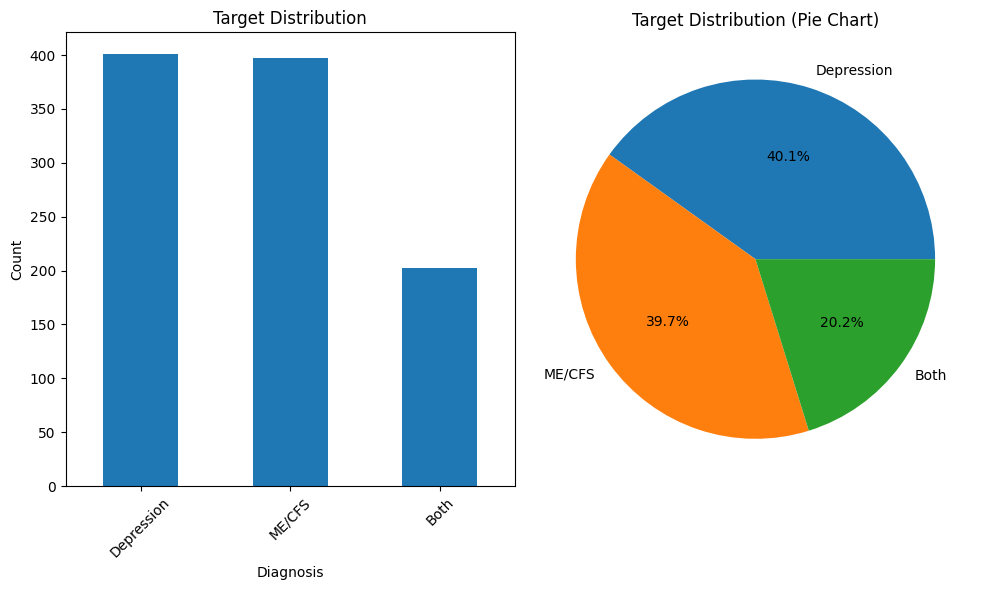

In [147]:
print("\n5.1 Target Distribution:")
target_dist = df_clean['diagnosis'].value_counts()
print(target_dist)

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
target_dist.plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(target_dist.values, labels=target_dist.index, autopct='%1.1f%%')
plt.title('Target Distribution (Pie Chart)')

plt.tight_layout()
plt.savefig('./images/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## 5.2 Numerical Features Distribution


5.2 Numerical Features Distribution:


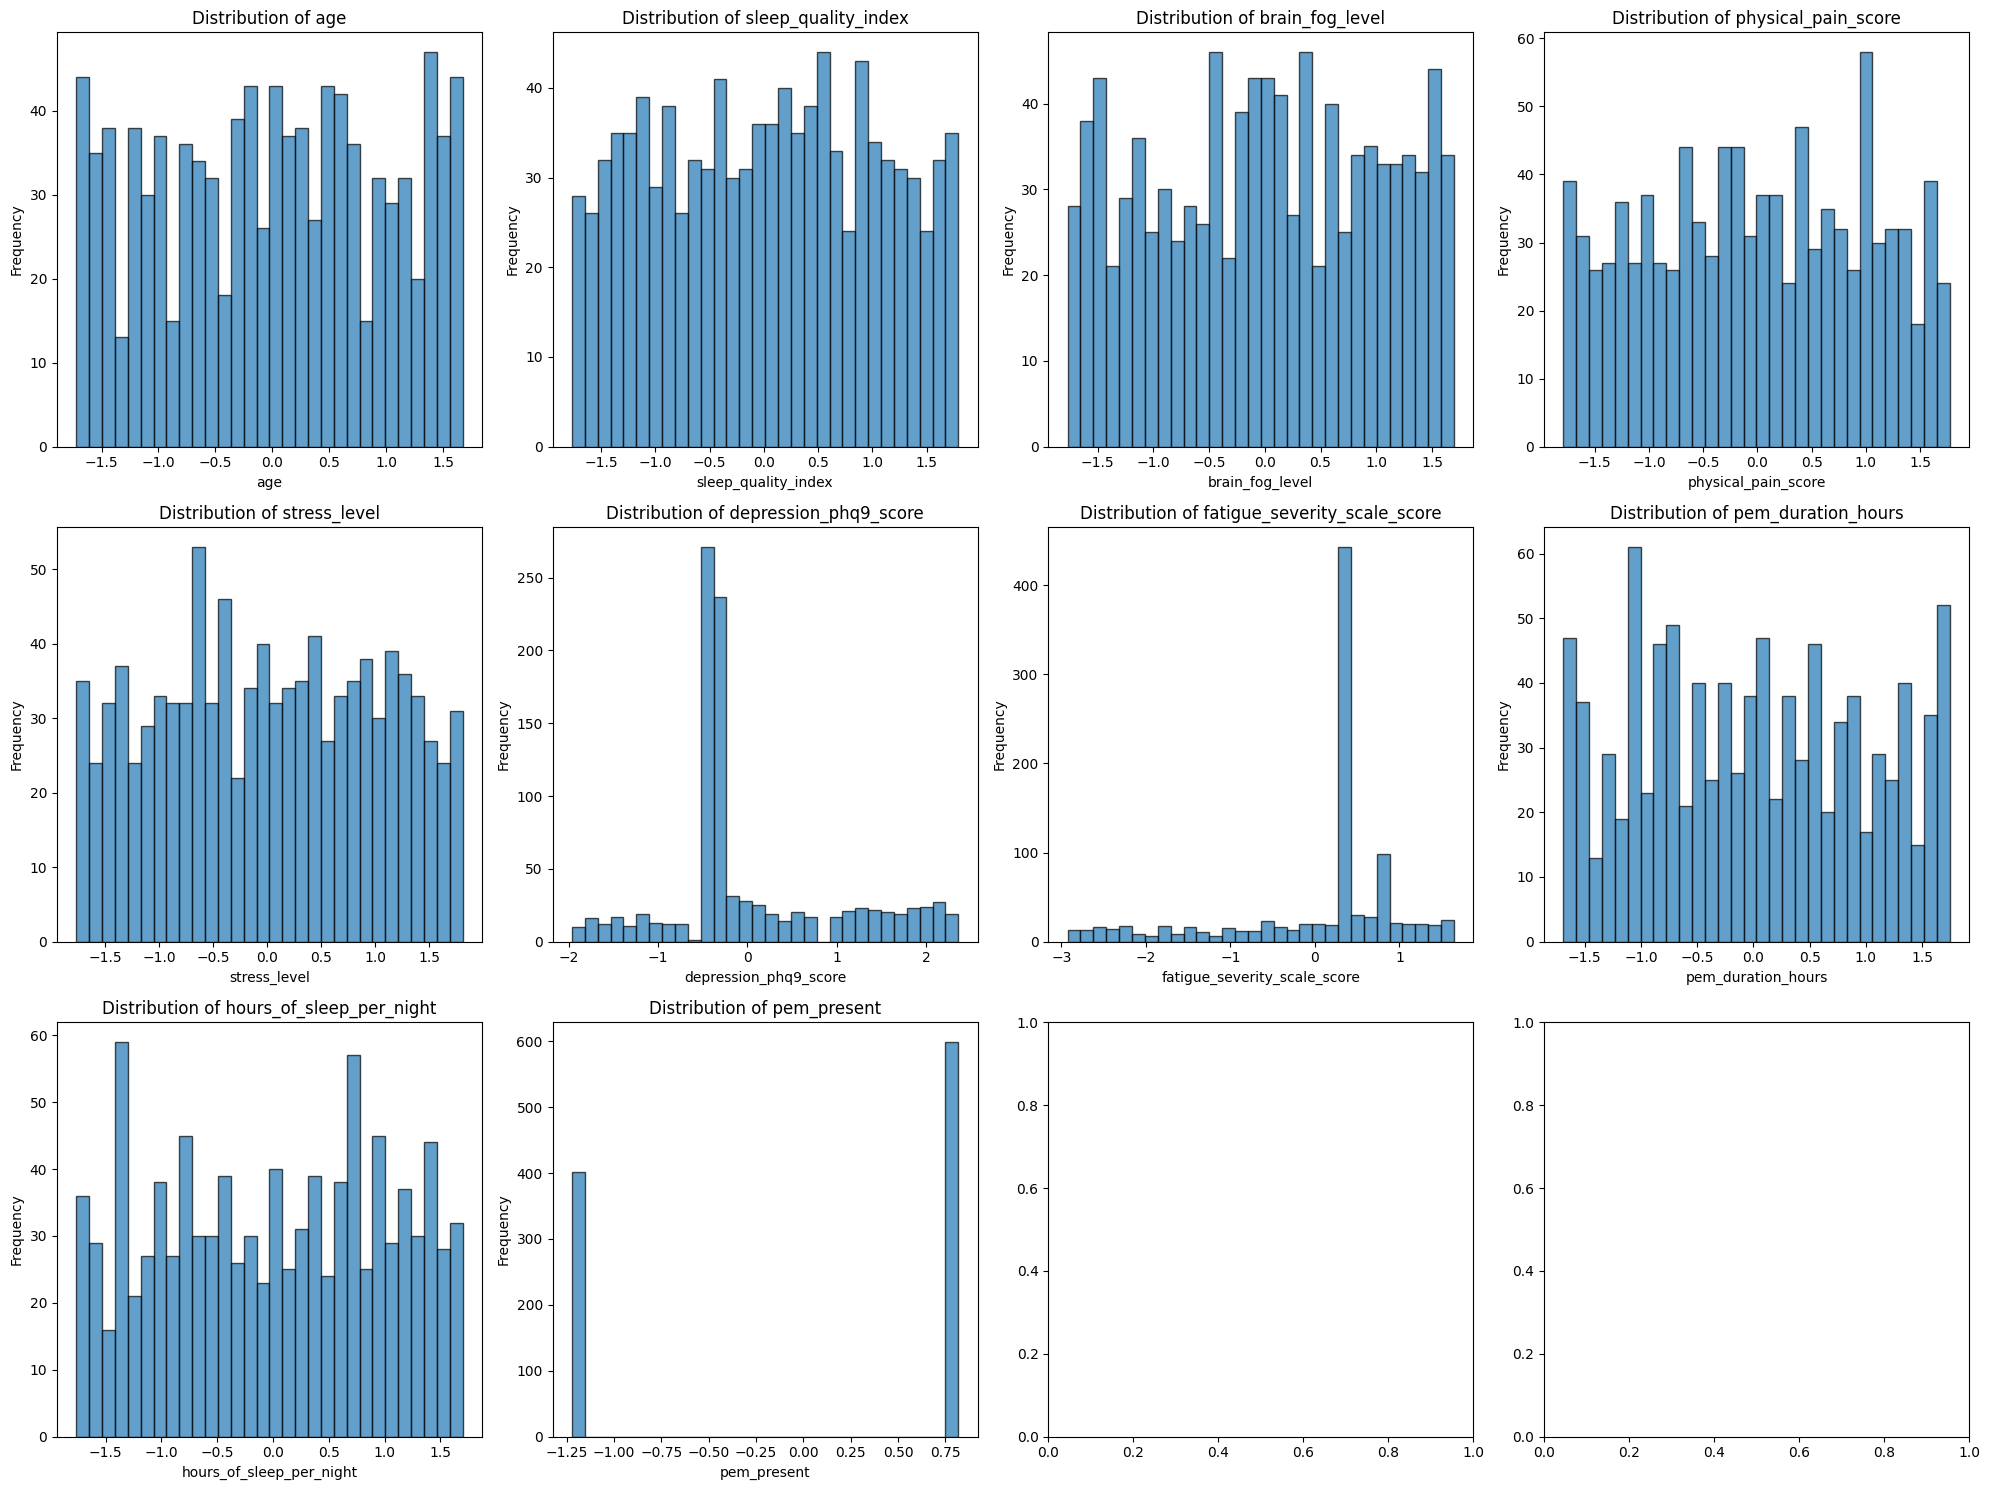

In [148]:
print("\n5.2 Numerical Features Distribution:")

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].hist(df_clean[col], bins=30, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('./images/numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


## 5.3 Correlation Analysis

Calculate correlation matrix

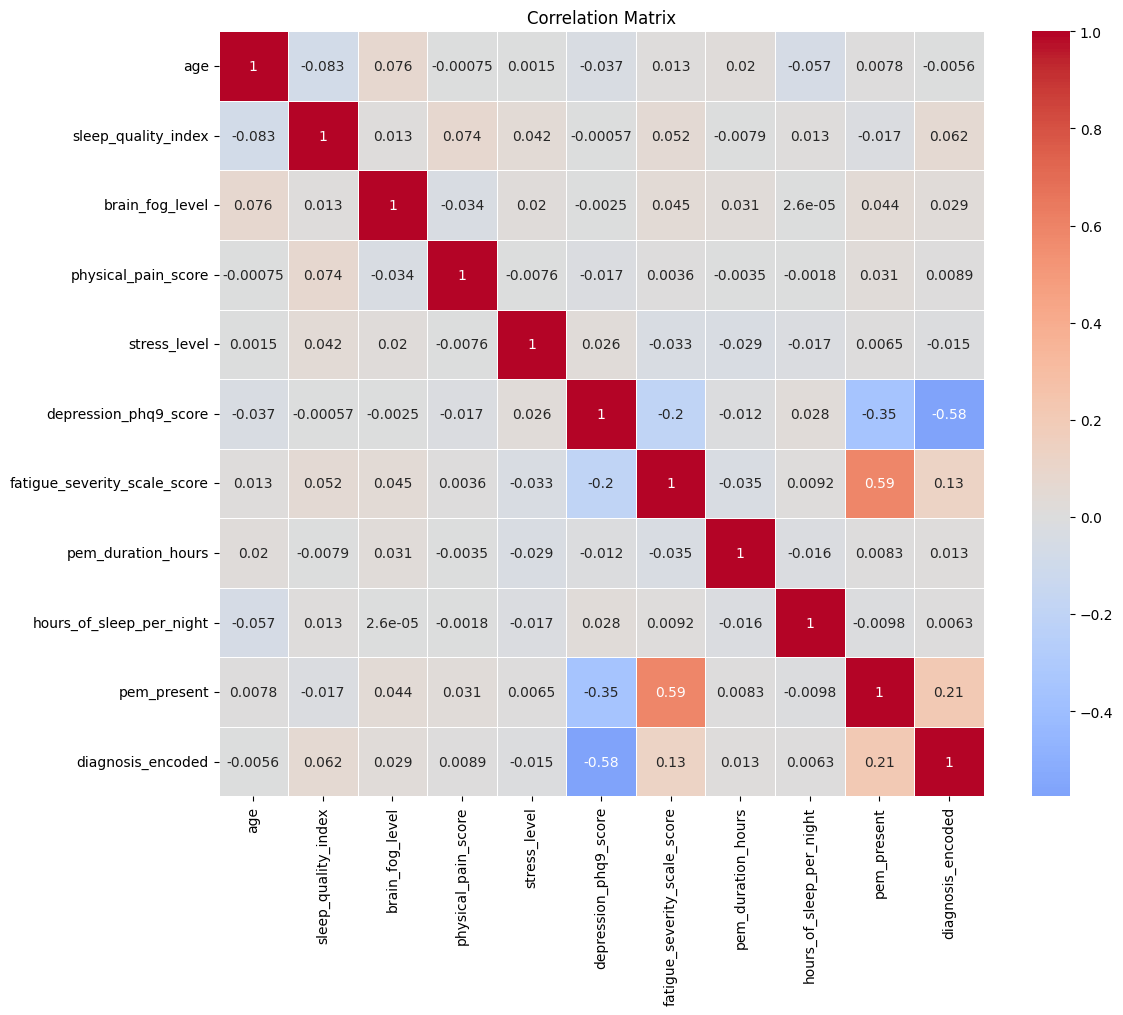

In [149]:
correlation_matrix = df_clean[numerical_cols + ['diagnosis_encoded']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('./images/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


## 5.4 Feature vs Target Analysis

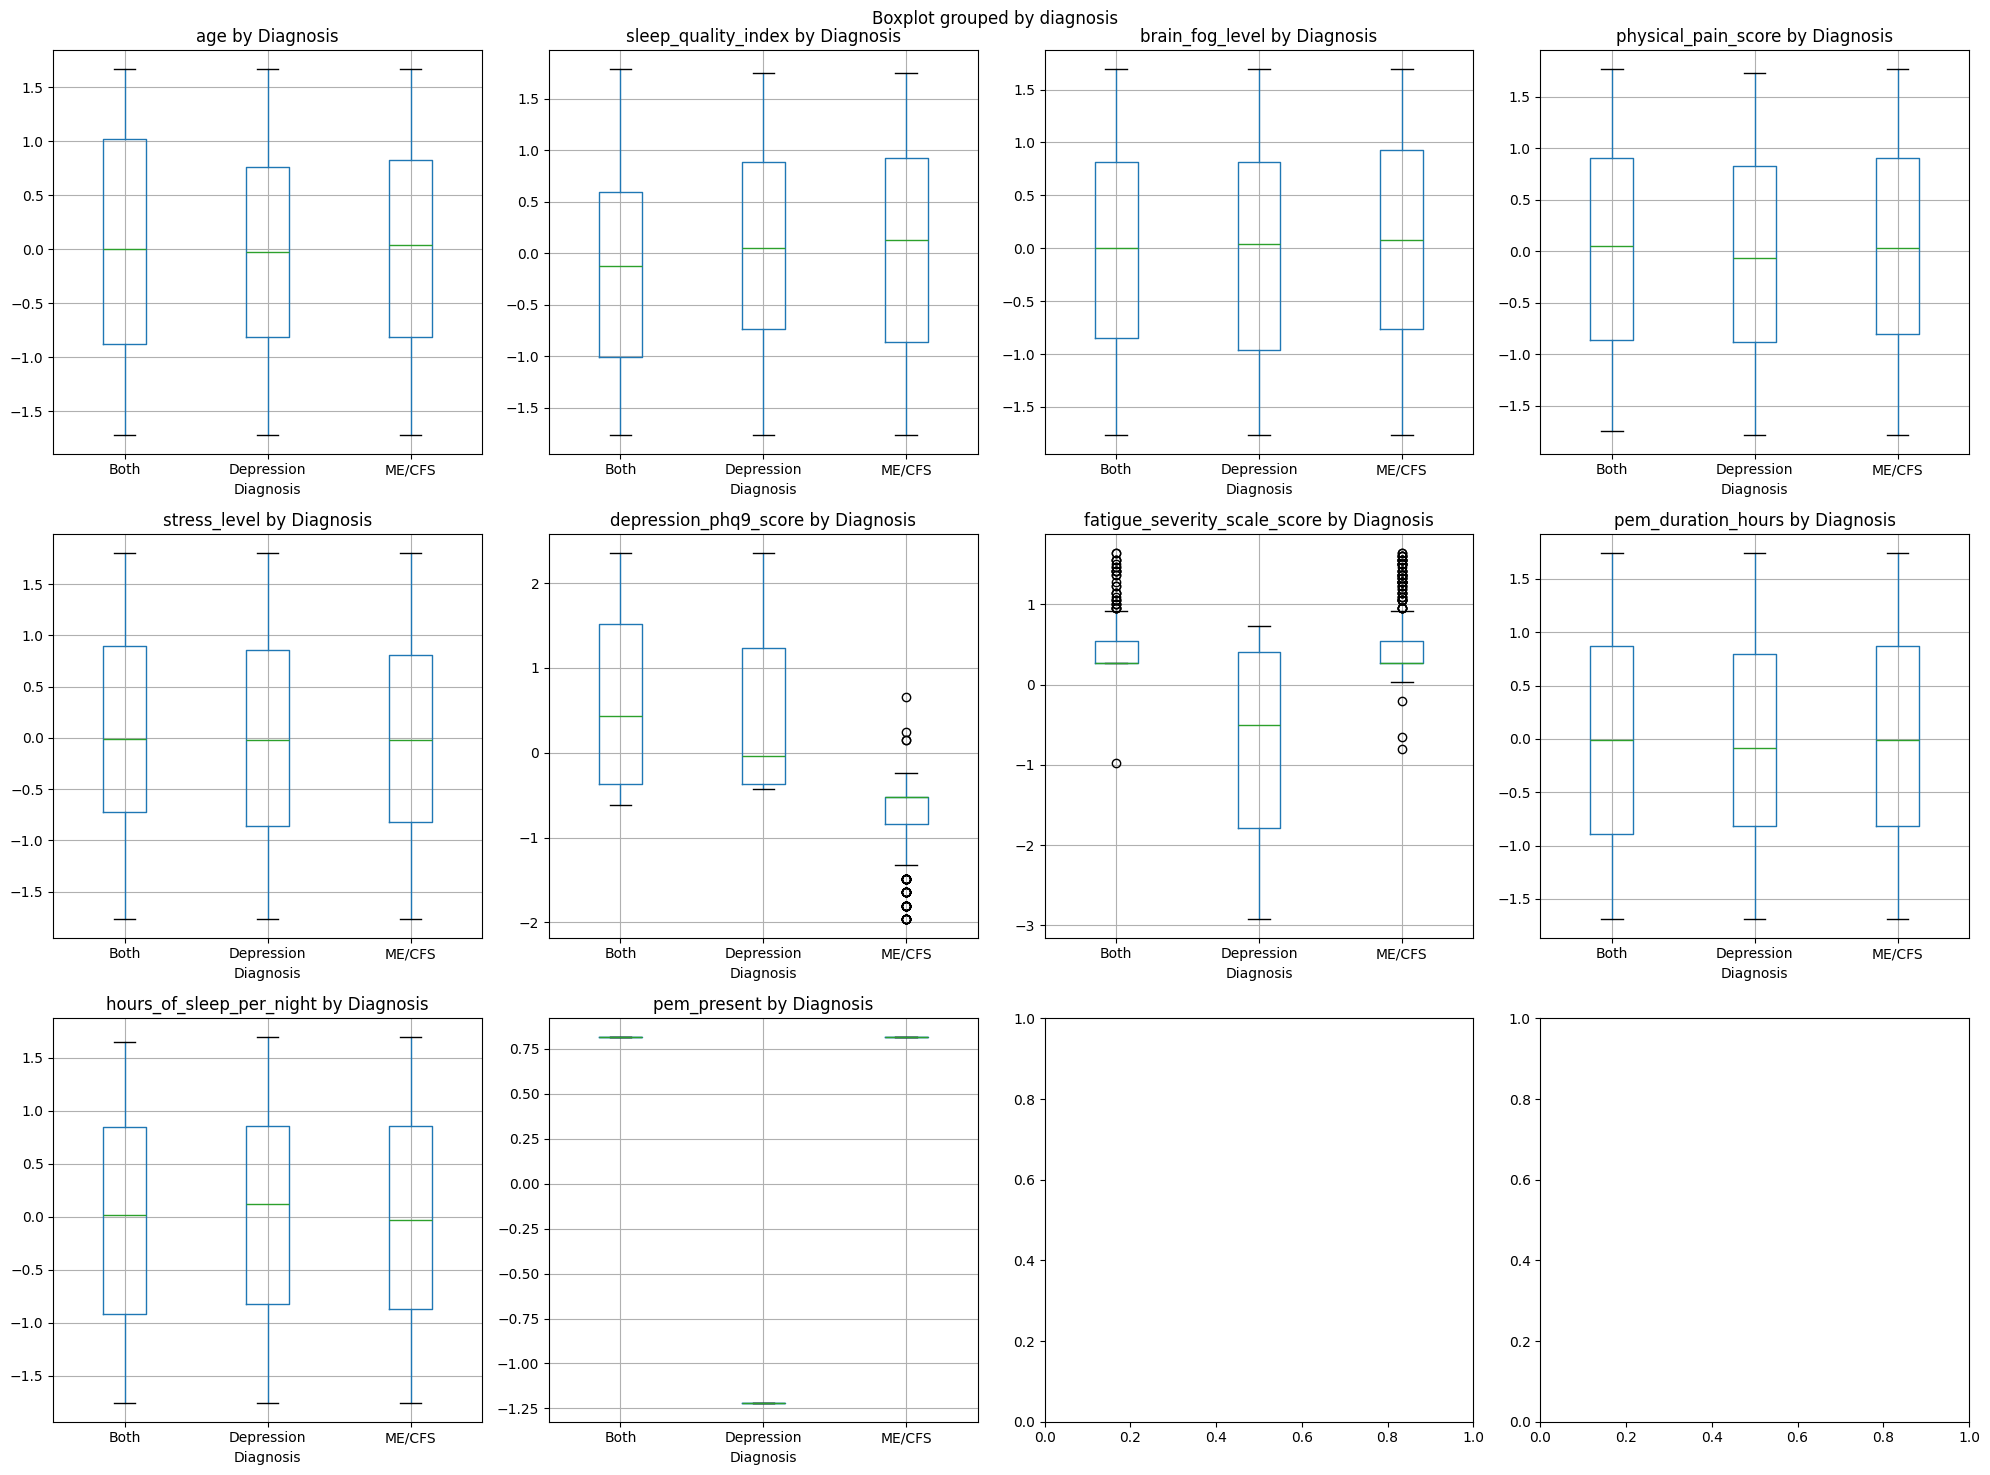

In [150]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        df_clean.boxplot(column=col, by='diagnosis', ax=axes[i])
        axes[i].set_title(f'{col} by Diagnosis')
        axes[i].set_xlabel('Diagnosis')

plt.tight_layout()
plt.savefig('./images/feature_vs_target.png', dpi=300, bbox_inches='tight')
plt.show()


## 5.5 Outlier Detection

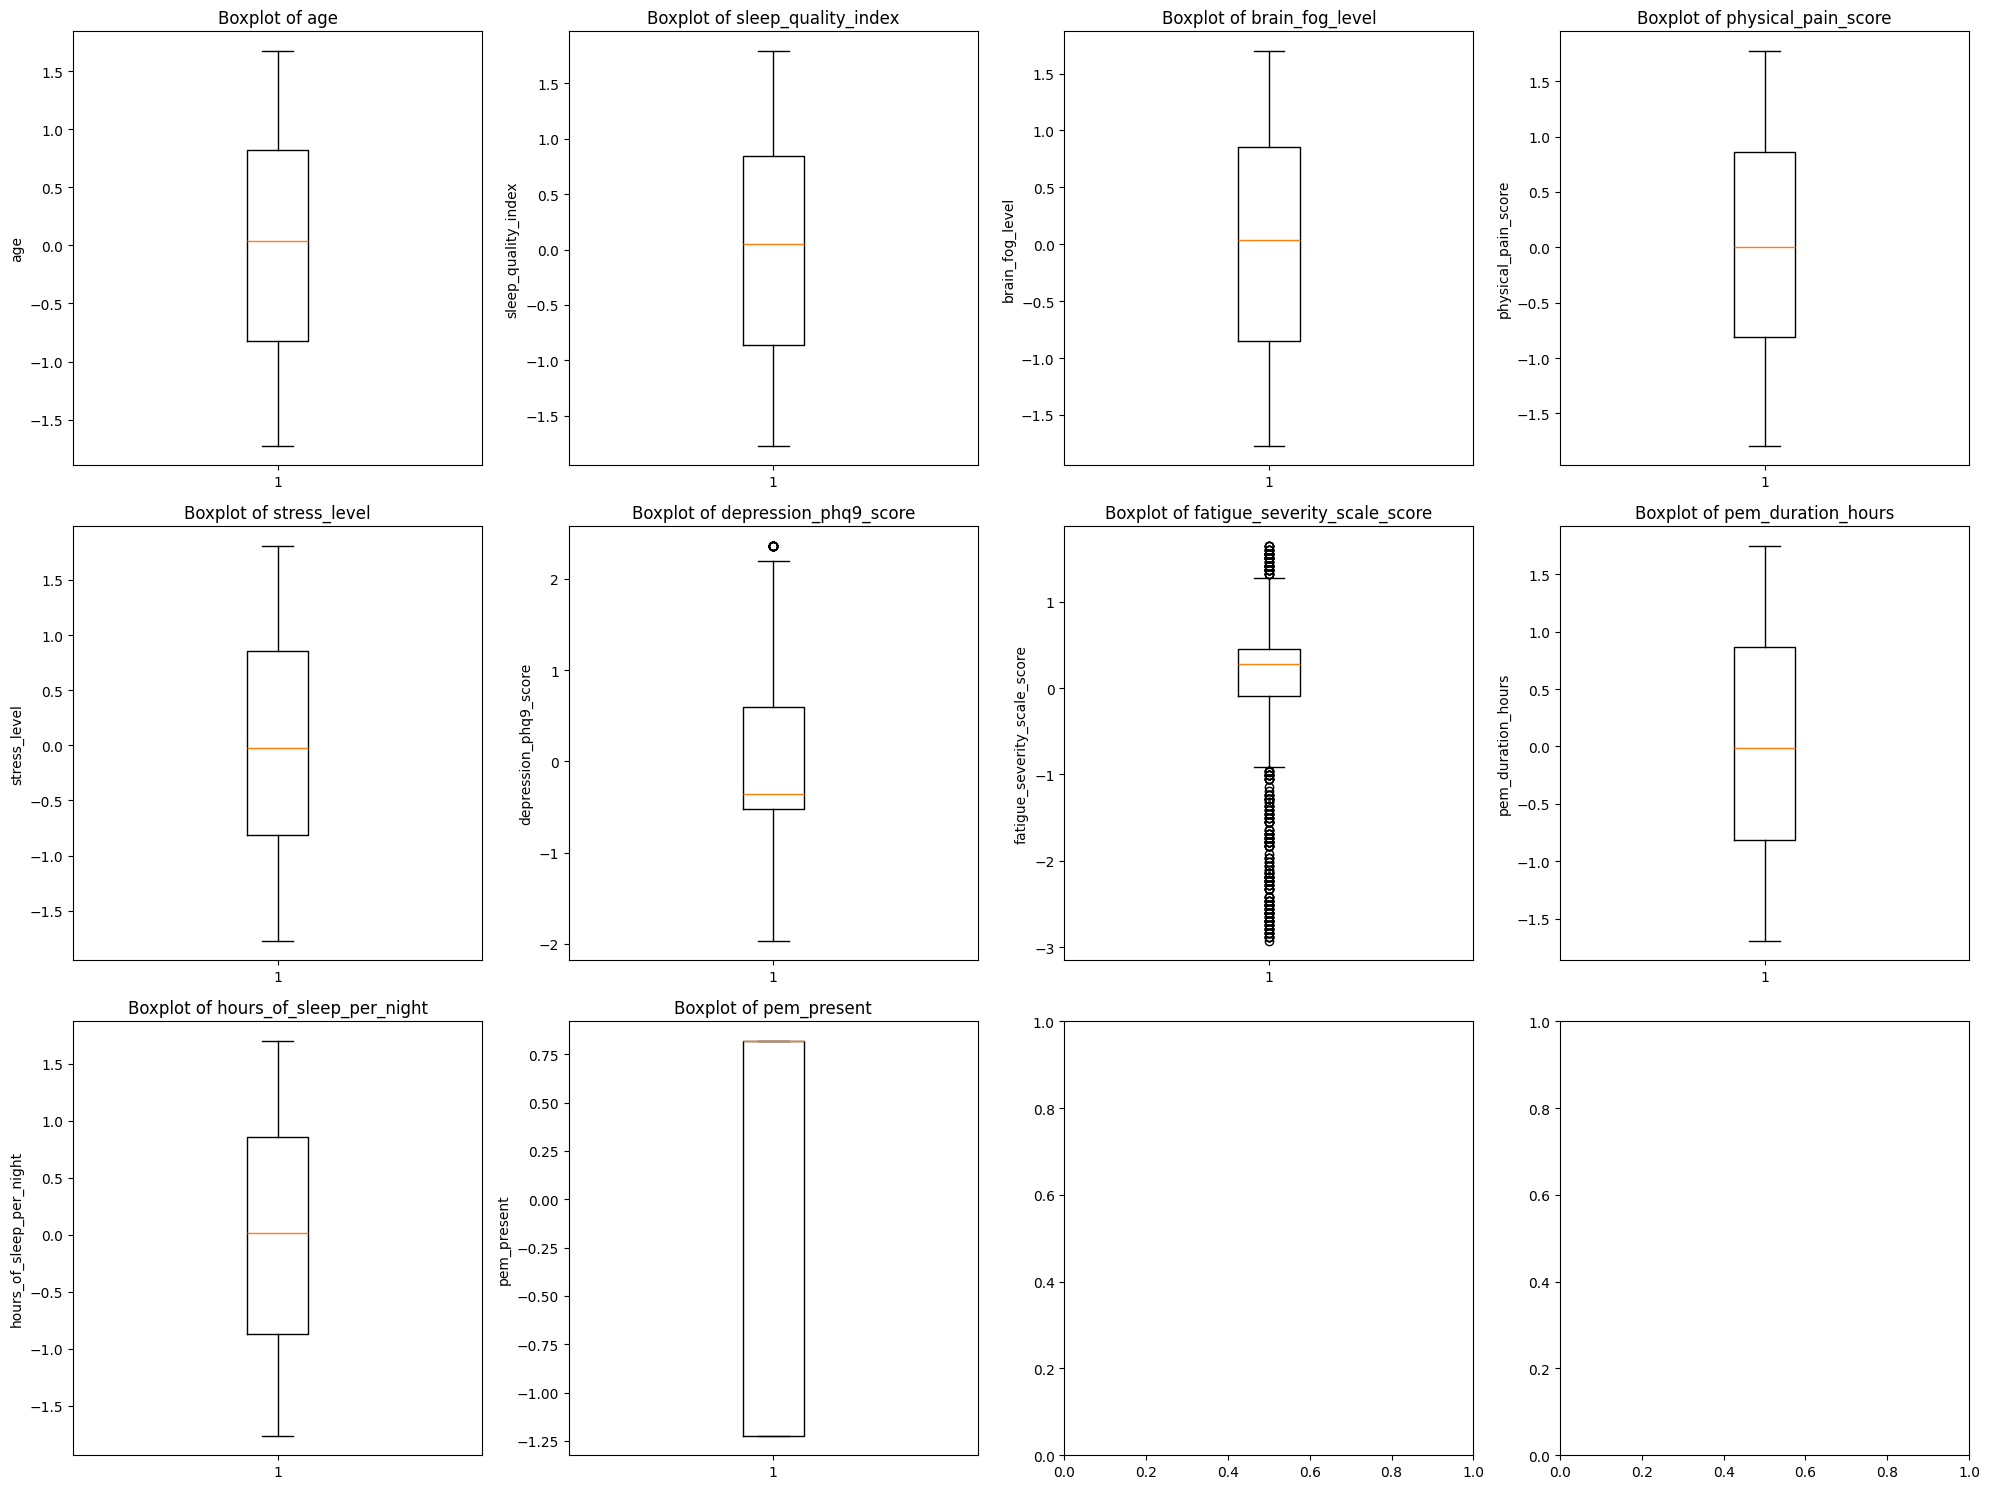

In [151]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].boxplot(df_clean[col])
        axes[i].set_title(f'Boxplot of {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('./images/outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()


# 6. FEATURE ENGINEERING AND SELECTION

## 6.1 Feature Engineering

Create new features

In [152]:
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0, 30, 50, 70, 100], 
                              labels=['Young', 'Middle', 'Senior', 'Elderly'])


Create interaction features

In [153]:
df_clean['fatigue_pain_interaction'] = df_clean['fatigue_severity_scale_score'] * df_clean['physical_pain_score']
df_clean['stress_depression_interaction'] = df_clean['stress_level'] * df_clean['depression_phq9_score']


Create ratio features

In [154]:
df_clean['sleep_efficiency'] = df_clean['hours_of_sleep_per_night'] / df_clean['sleep_quality_index']


Encode new categorical features

In [155]:
le_age = LabelEncoder()
df_clean['age_group_encoded'] = le_age.fit_transform(df_clean['age_group'])


## 6.2 Feature Selection

Prepare features and target

In [156]:
feature_cols = [col for col in df_clean.columns if col not in ['diagnosis', 'diagnosis_encoded', 'age_group']]
X = df_clean[feature_cols]
y = df_clean['diagnosis_encoded']


Method 1: SelectKBest

In [157]:
print("Feature selection using SelectKBest:")
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()
print(f"Selected features: {selected_features}")


Feature selection using SelectKBest:
Selected features: ['sleep_quality_index', 'brain_fog_level', 'depression_phq9_score', 'fatigue_severity_scale_score', 'pem_present', 'work_status', 'social_activity_level', 'meditation_or_mindfulness', 'stress_depression_interaction', 'sleep_efficiency']


Method 2: Random Forest Feature Importance

In [158]:
print("\nFeature importance using Random Forest:")
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X, y)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 most important features:")
print(feature_importance.head(10))



Feature importance using Random Forest:
Top 10 most important features:
                          feature  importance
6           depression_phq9_score    0.400279
10                    pem_present    0.294623
7    fatigue_severity_scale_score    0.163339
15       fatigue_pain_interaction    0.023790
16  stress_depression_interaction    0.020651
5                    stress_level    0.019974
4             physical_pain_score    0.010958
17               sleep_efficiency    0.010652
3                 brain_fog_level    0.009349
2             sleep_quality_index    0.009086


Plot feature importance

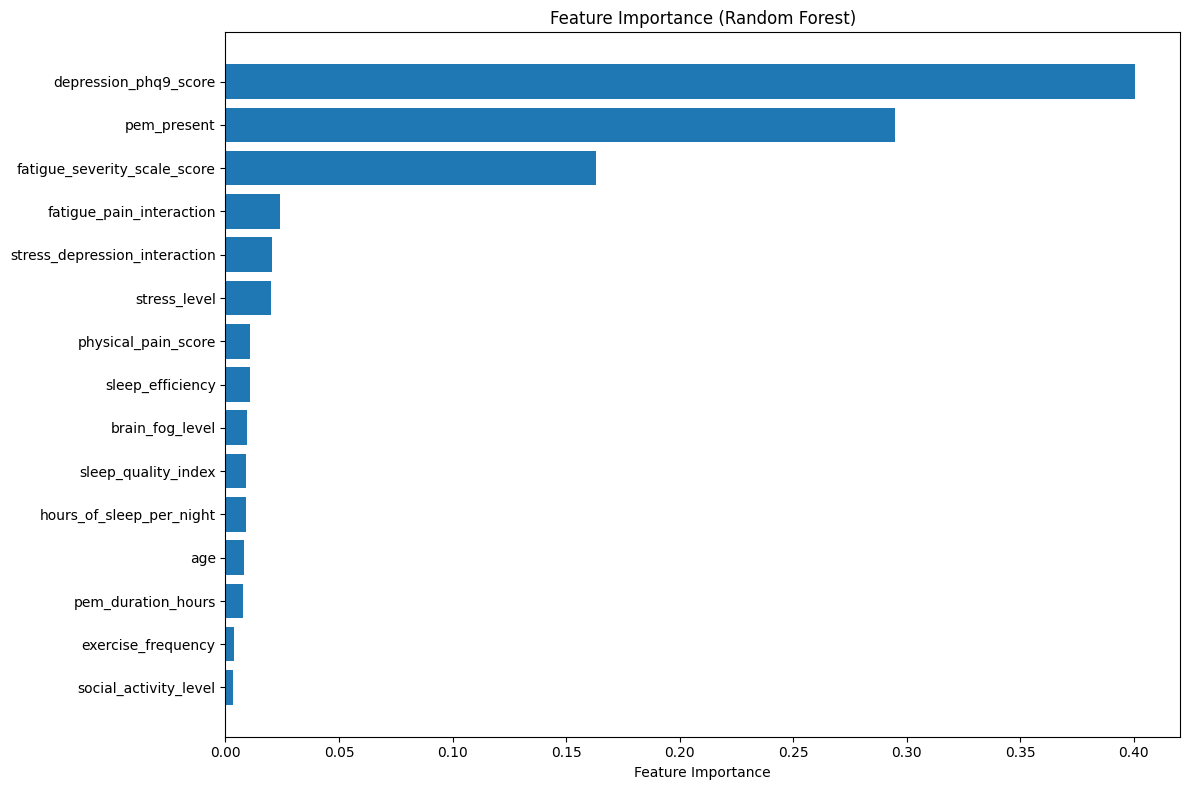

In [159]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('./images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


Select final features

In [160]:
final_features = feature_importance.head(15)['feature'].tolist()
X_final = X[final_features]

print(f"\nFinal selected features: {final_features}")



Final selected features: ['depression_phq9_score', 'pem_present', 'fatigue_severity_scale_score', 'fatigue_pain_interaction', 'stress_depression_interaction', 'stress_level', 'physical_pain_score', 'sleep_efficiency', 'brain_fog_level', 'sleep_quality_index', 'hours_of_sleep_per_night', 'age', 'pem_duration_hours', 'exercise_frequency', 'social_activity_level']


# 7. DATA PREPARATION FOR MODELING

## 7.1 Split the data

In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Training set shape: (800, 15)
Test set shape: (200, 15)


## 7.2 Handle Class Imbalance

Check class distribution

In [162]:
print("Class distribution in training set:")
print(pd.Series(y_train).value_counts())


Class distribution in training set:
diagnosis_encoded
1    321
2    318
0    161
Name: count, dtype: int64


Apply SMOTE for oversampling

In [163]:
print("\nApplying SMOTE for oversampling...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts())



Applying SMOTE for oversampling...
Class distribution after SMOTE:
diagnosis_encoded
2    321
1    321
0    321
Name: count, dtype: int64


7.3 Final Scaling

In [164]:
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_balanced)
X_test_scaled = scaler_final.transform(X_test)


# 8. MACHINE LEARNING MODEL TRAINING

## 8.1 Define models

In [165]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}


## 8.2 Train and evaluate models

In [166]:
ml_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train_balanced)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    
    ml_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc:.4f}")


Training Logistic Regression...
Logistic Regression - Accuracy: 0.9400, F1: 0.9370, ROC AUC: 0.9969

Training Random Forest...
Random Forest - Accuracy: 1.0000, F1: 1.0000, ROC AUC: 1.0000

Training SVM...
SVM - Accuracy: 0.8950, F1: 0.8914, ROC AUC: 0.9734

Training Gradient Boosting...
Gradient Boosting - Accuracy: 1.0000, F1: 1.0000, ROC AUC: 1.0000

Training KNN...
KNN - Accuracy: 0.7850, F1: 0.7914, ROC AUC: 0.9080

Training Naive Bayes...
Naive Bayes - Accuracy: 0.8900, F1: 0.8817, ROC AUC: 0.9572

Training Decision Tree...
Decision Tree - Accuracy: 1.0000, F1: 1.0000, ROC AUC: 1.0000


## 8.3 Compare ML models

In [167]:
print("\n8.3 Machine Learning Models Comparison:")

ml_comparison = pd.DataFrame({
    'Model': list(ml_results.keys()),
    'Accuracy': [results['accuracy'] for results in ml_results.values()],
    'Precision': [results['precision'] for results in ml_results.values()],
    'Recall': [results['recall'] for results in ml_results.values()],
    'F1-Score': [results['f1'] for results in ml_results.values()],
    'ROC AUC': [results['roc_auc'] for results in ml_results.values()]
})

print(ml_comparison.sort_values('F1-Score', ascending=False))



8.3 Machine Learning Models Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score   ROC AUC
1        Random Forest     1.000   1.000000   1.000  1.000000  1.000000
6        Decision Tree     1.000   1.000000   1.000  1.000000  1.000000
3    Gradient Boosting     1.000   1.000000   1.000  1.000000  1.000000
0  Logistic Regression     0.940   0.947912   0.940  0.936975  0.996939
2                  SVM     0.895   0.894233   0.895  0.891357  0.973441
5          Naive Bayes     0.890   0.896400   0.890  0.881724  0.957170
4                  KNN     0.785   0.806103   0.785  0.791444  0.907997


Plot comparison

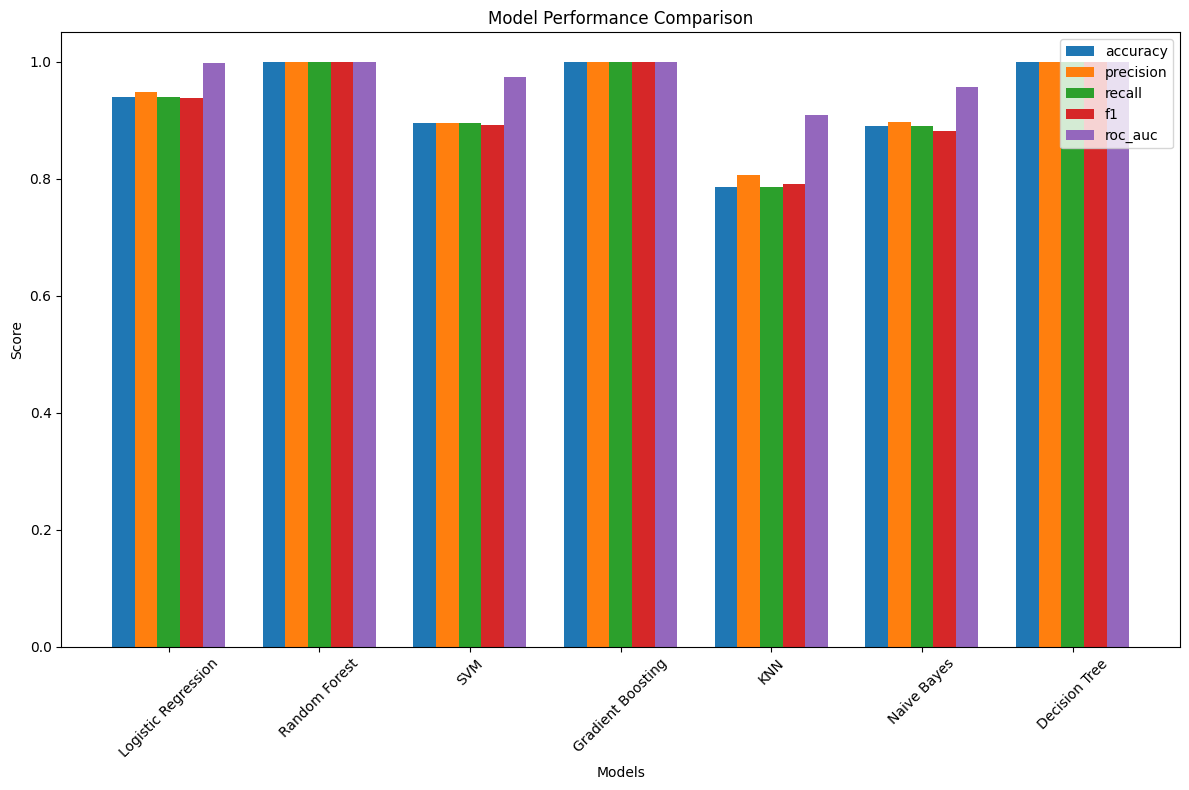

In [168]:
plt.figure(figsize=(12, 8))
# for model in ml_results.keys():
#     print(f"{model}: {ml_results[model].keys()}")
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(ml_results))
width = 0.15

for i, metric in enumerate(metrics):
    values = [ml_results[model][metric] for model in ml_results.keys()]
    plt.bar(x + i*width, values, width, label=metric)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x + width*2, list(ml_results.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('./images/ml_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# 9. DEEP LEARNING MODEL

## 9.1 Prepare data for deep learning

In [169]:
X_train_dl = X_train_scaled
X_test_dl = X_test_scaled
y_train_dl = tf.keras.utils.to_categorical(y_train_balanced, num_classes=3)
y_test_dl = tf.keras.utils.to_categorical(y_test, num_classes=3)


## 9.2 Build Deep Learning Model

In [170]:
def create_dl_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


## 9.3 Create and train the model

In [171]:
print("Building Deep Learning model...")
dl_model = create_dl_model(X_train_dl.shape[1], 3)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

# Train the model
history = dl_model.fit(
    X_train_dl, y_train_dl,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Building Deep Learning model...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.5269 - loss: 0.9713 - val_accuracy: 0.2124 - val_loss: 1.0590 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7776 - loss: 0.6353 - val_accuracy: 0.3368 - val_loss: 0.9138 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8448 - loss: 0.3938 - val_accuracy: 0.5285 - val_loss: 0.7206 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8974 - loss: 0.3182 - val_accuracy: 0.6269 - val_loss: 0.5824 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9129 - loss: 0.2570 - val_accuracy: 0.6425 - val_loss: 0.5247 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9168 - loss: 0.2270 - val_accuracy: 0.6166 - val_loss: 0.6139 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

## 9.4 Evaluate Deep Learning Model

In [172]:
# Predictions
y_pred_dl = dl_model.predict(X_test_dl)
y_pred_classes = np.argmax(y_pred_dl, axis=1)
y_test_classes = np.argmax(y_test_dl, axis=1)

# Calculate metrics
dl_accuracy = accuracy_score(y_test_classes, y_pred_classes)
dl_precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
dl_recall = recall_score(y_test_classes, y_pred_classes, average='weighted')
dl_f1 = f1_score(y_test_classes, y_pred_classes, average='weighted')
dl_roc_auc = roc_auc_score(y_test_classes, y_pred_dl, multi_class='ovr')

print(f"Deep Learning Model - Accuracy: {dl_accuracy:.4f}, F1: {dl_f1:.4f}, ROC AUC: {dl_roc_auc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Deep Learning Model - Accuracy: 0.9150, F1: 0.9121, ROC AUC: 0.9794


## 9.5 Plot training history

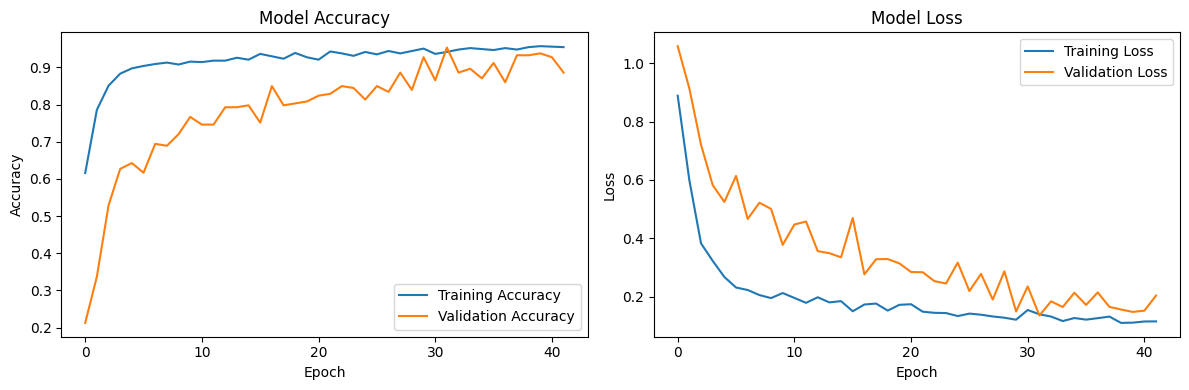

In [173]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('./images/dl_training_history.png', dpi=300, bbox_inches='tight')
plt.show()


# 10. MODEL EVALUATION AND TUNING

## 10.1 Best ML Model Selection

In [174]:
best_ml_model_name = max(ml_results.keys(), key=lambda x: ml_results[x]['f1'])
best_ml_model = ml_results[best_ml_model_name]['model']
print(f"Best ML Model: {best_ml_model_name}")


Best ML Model: Random Forest


## 10.2 Hyperparameter Tuning for Best ML Model

In [175]:
print(f"\n10.2 Hyperparameter Tuning for {best_ml_model_name}")

if best_ml_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif best_ml_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
elif best_ml_model_name == 'SVM':
    param_grid = {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }
else:
    param_grid = {}

if param_grid:
    # Grid search
    grid_search = GridSearchCV(
        best_ml_model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train_balanced)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    # Use best model
    best_tuned_model = grid_search.best_estimator_
    y_pred_tuned = best_tuned_model.predict(X_test_scaled)
    y_pred_proba_tuned = best_tuned_model.predict_proba(X_test_scaled)
    
    # Calculate metrics for tuned model
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
    tuned_roc_auc = roc_auc_score(y_test, y_pred_proba_tuned, multi_class='ovr')
    
    print(f"Tuned {best_ml_model_name} - Accuracy: {tuned_accuracy:.4f}, F1: {tuned_f1:.4f}, ROC AUC: {tuned_roc_auc:.4f}")


10.2 Hyperparameter Tuning for Random Forest
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation score: 0.9927
Tuned Random Forest - Accuracy: 1.0000, F1: 1.0000, ROC AUC: 1.0000


## 10.3 Final Model Comparison

In [176]:
print("\n10.3 Final Model Comparison:")

final_comparison = pd.DataFrame({
    'Model': ['Best ML (Original)', 'Best ML (Tuned)', 'Deep Learning'],
    'Accuracy': [
        ml_results[best_ml_model_name]['accuracy'],
        tuned_accuracy if 'tuned_accuracy' in locals() else ml_results[best_ml_model_name]['accuracy'],
        dl_accuracy
    ],
    'F1-Score': [
        ml_results[best_ml_model_name]['f1'],
        tuned_f1 if 'tuned_f1' in locals() else ml_results[best_ml_model_name]['f1'],
        dl_f1
    ],
    'ROC AUC': [
        ml_results[best_ml_model_name]['roc_auc'],
        tuned_roc_auc if 'tuned_roc_auc' in locals() else ml_results[best_ml_model_name]['roc_auc'],
        dl_roc_auc
    ]
})

print(final_comparison)



10.3 Final Model Comparison:
                Model  Accuracy  F1-Score   ROC AUC
0  Best ML (Original)     1.000  1.000000  1.000000
1     Best ML (Tuned)     1.000  1.000000  1.000000
2       Deep Learning     0.915  0.912051  0.979445


## 10.4 Confusion Matrix for Best Models


10.4 Confusion Matrices:


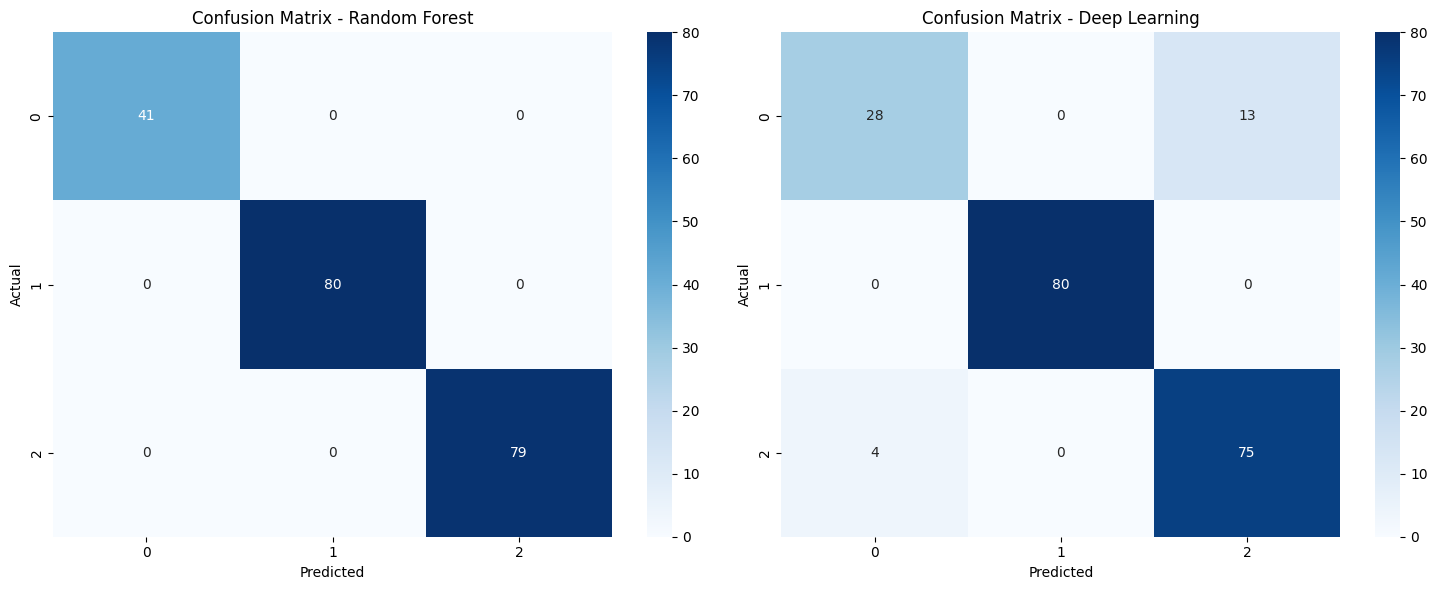

In [177]:
print("\n10.4 Confusion Matrices:")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Best ML Model
best_ml_pred = ml_results[best_ml_model_name]['predictions']
cm_ml = confusion_matrix(y_test, best_ml_pred)
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_ml_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Deep Learning Model
cm_dl = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Deep Learning')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('./images/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## 10.5 Classification Reports

In [178]:
print(f"\nClassification Report - {best_ml_model_name}:")
print(classification_report(y_test, best_ml_pred, target_names=target_encoder.classes_))

print("\nClassification Report - Deep Learning:")
print(classification_report(y_test_classes, y_pred_classes, target_names=target_encoder.classes_))



Classification Report - Random Forest:
              precision    recall  f1-score   support

        Both       1.00      1.00      1.00        41
  Depression       1.00      1.00      1.00        80
      ME/CFS       1.00      1.00      1.00        79

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Classification Report - Deep Learning:
              precision    recall  f1-score   support

        Both       0.88      0.68      0.77        41
  Depression       1.00      1.00      1.00        80
      ME/CFS       0.85      0.95      0.90        79

    accuracy                           0.92       200
   macro avg       0.91      0.88      0.89       200
weighted avg       0.92      0.92      0.91       200



# 11. FEATURE IMPORTANCE ANALYSIS

For Random Forest

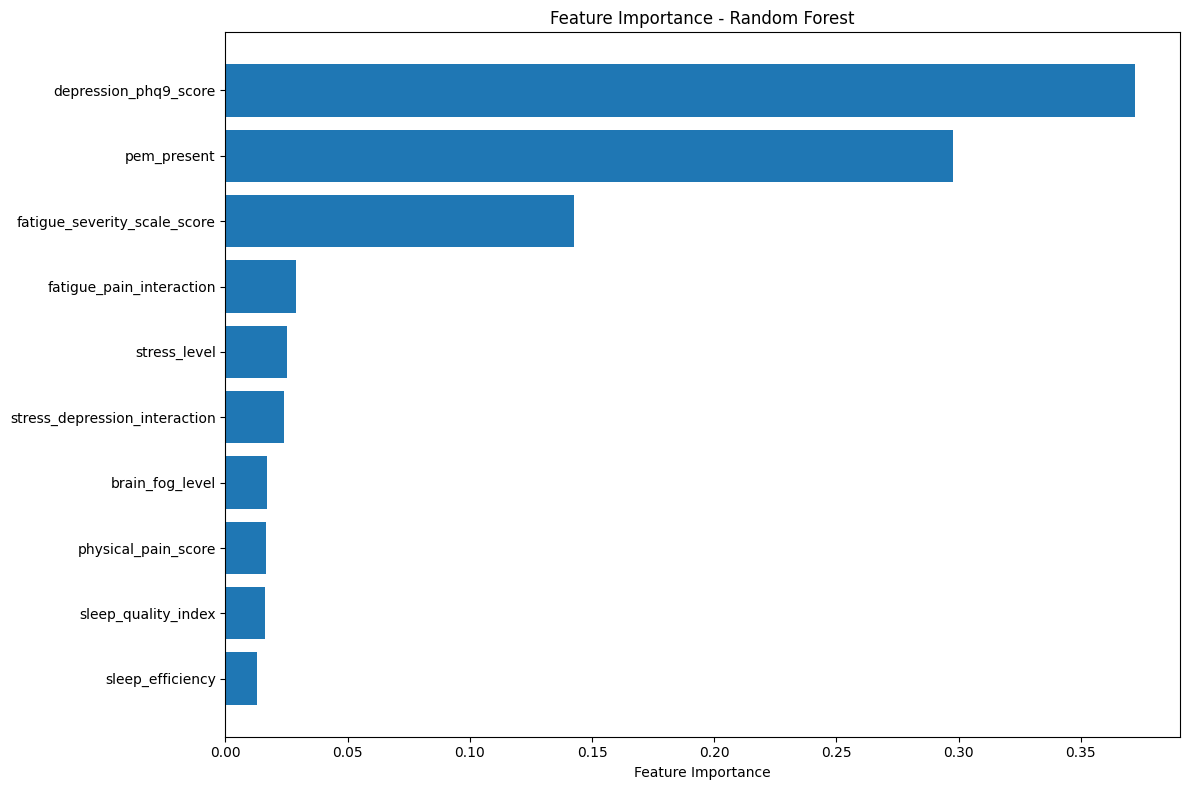

In [179]:
if best_ml_model_name == 'Random Forest':
    feature_importance_final = pd.DataFrame({
        'feature': X_final.columns,
        'importance': best_ml_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_final.head(10)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance - {best_ml_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('./images/final_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


# 12. MODEL INTERPRETATION AND INSIGHTS

In [180]:
print("\nKey Findings:")
print("1. Dataset Characteristics:")
print(f"   - Total samples: {len(df)}")
print(f"   - Features: {len(X_final.columns)}")
print(f"   - Classes: {len(target_encoder.classes_)}")

print("\n2. Data Quality:")
print(f"   - Missing values handled: {missing_df['Missing_Count'].sum()}")
print(f"   - Duplicate rows removed: {df.duplicated().sum()}")

print("\n3. Model Performance:")
best_model_name = final_comparison.loc[final_comparison['F1-Score'].idxmax(), 'Model']
best_f1 = final_comparison['F1-Score'].max()
print(f"   - Best performing model: {best_model_name}")
print(f"   - Best F1-Score: {best_f1:.4f}")

print("\n4. Feature Insights:")
if 'feature_importance_final' in locals():
    top_3_features = feature_importance_final.head(3)['feature'].tolist()
    print(f"   - Top 3 most important features: {top_3_features}")

print("\n5. Clinical Implications:")
print("   - The model can help differentiate between ME/CFS and Depression")
print("   - Key features include sleep quality, fatigue severity, and physical pain")
print("   - Model can assist in early diagnosis and treatment planning")



Key Findings:
1. Dataset Characteristics:
   - Total samples: 1000
   - Features: 15
   - Classes: 3

2. Data Quality:
   - Missing values handled: 402
   - Duplicate rows removed: 0

3. Model Performance:
   - Best performing model: Best ML (Original)
   - Best F1-Score: 1.0000

4. Feature Insights:
   - Top 3 most important features: ['depression_phq9_score', 'pem_present', 'fatigue_severity_scale_score']

5. Clinical Implications:
   - The model can help differentiate between ME/CFS and Depression
   - Key features include sleep quality, fatigue severity, and physical pain
   - Model can assist in early diagnosis and treatment planning


# 13. SAVE MODELS AND RESULTS

In [181]:
import joblib
import json
os.makedirs('models', exist_ok=True)

# Save best ML model
joblib.dump(best_ml_model, './models/best_ml_model.pkl')

# Save deep learning model
dl_model.save('./models/deep_learning_model.h5')

# Save scaler
joblib.dump(scaler_final, './models/scaler.pkl')

# Save encoders
joblib.dump(target_encoder, './models/target_encoder.pkl')
joblib.dump(label_encoders, './models/label_encoders.pkl')

# Save results
results_summary = {
    'best_ml_model': best_ml_model_name,
    'best_ml_accuracy': ml_results[best_ml_model_name]['accuracy'],
    'best_ml_f1': ml_results[best_ml_model_name]['f1'],
    'dl_accuracy': dl_accuracy,
    'dl_f1': dl_f1,
    'feature_importance': feature_importance_final.to_dict() if 'feature_importance_final' in locals() else None,
    'selected_features': final_features
}

with open('./models/model_results.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

print("Models and results saved successfully!")

Models and results saved successfully!


# 14. CONCLUSION

In [182]:
print(f"\nBest Model: {best_model_name}")
print(f"Performance: F1-Score = {best_f1:.4f}")


Best Model: Best ML (Original)
Performance: F1-Score = 1.0000
